In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys,os
import math
sys.path.append(os.path.abspath("../Paraproducts"))
from tensor_paraproducts import haar_paraproduct 
import pickle

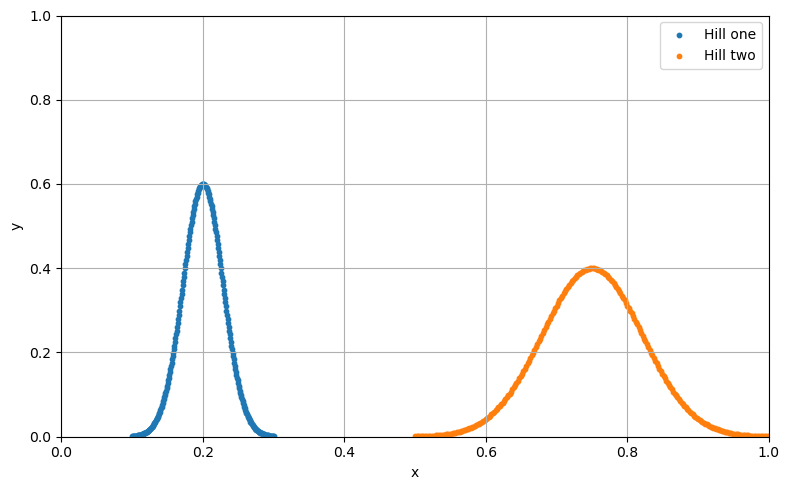

In [2]:

# Data generation
N = 256

# Hill: x evenly spaced in [0.3, 0.5], y is a Gaussian bell curve + small noise
hill_x = np.linspace(0.1, 0.3, N)
hill_y = np.exp(-((hill_x - 0.2) / 0.04) ** 2) * 0.6 #+ np.random.uniform(0, 0.05, N)

# Hill: x evenly spaced in [0.3, 0.5], y is a Gaussian bell curve + small noise
hill_xt = np.linspace(0.5, 1, N)
hill_yt = np.exp(-((hill_xt - 0.75) / 0.1) ** 2) * 0.4 #+ np.random.uniform(0, 0.05, N)

plt.figure(figsize=(8, 5))
plt.scatter(hill_x, hill_y, s=10, label='Hill one')
plt.scatter(hill_xt, hill_yt, s=10, label='Hill two')
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [3]:
# Utility function for computing percentage of coefficients needed to reach entropy tolerance

def ncoefs(vec,tol):

    scoef = np.flip(np.sort(vec))
    totscoef = np.sum(scoef)
    val = 0
    for i in range(len(scoef)):
        val += scoef[i]
        if val/totscoef > tol:
            break
    per = i/len(scoef)
    
    return per

In [4]:
# Initialization
datadict = {}
dims = [64,128,256,512]
times = [0.0005,0.005,0.05,0.5]
scales = [4,5,6,7]

for N in dims:
    for t in times:
        for mxscl in scales:

            if mxscl > int(np.log2(N)):
                continue

            # Data Generation
            # Hill: x evenly spaced in [0.3, 0.5], y is a Gaussian bell curve + small noise
            hill_x = np.linspace(0.1, 0.3, N)
            hill_y = np.exp(-((hill_x - 0.2) / 0.04) ** 2) * 0.6 #+ np.random.uniform(0, 0.05, N)
            
            # Hill: x evenly spaced in [0.3, 0.5], y is a Gaussian bell curve + small noise
            hill_xt = np.linspace(0.5, 1, N)
            hill_yt = np.exp(-((hill_xt - 0.75) / 0.1) ** 2) * 0.4 #+ np.random.uniform(0, 0.05, N)
            
            hill_x = np.expand_dims(hill_x,axis=1)
            hill_y = np.expand_dims(hill_y,axis=1)
            
            hill_xt = np.expand_dims(hill_xt,axis=1)
            hill_yt = np.expand_dims(hill_yt,axis=1)
            
            u = np.concatenate((hill_x,hill_y),axis=1)
            v = np.concatenate((hill_xt,hill_yt),axis=1)
            data = [(u,v)]
            datadict['data_schrod'] = data
            
            # Compute distance matrix
            dxy = np.zeros((N,N))
            for i in range(N):
                for j in range(N):
                    dxy[i,j] = np.linalg.norm(u[i] - v[j])

            # Compute kernel
            phase = (dxy**2)/t
            datadict['phase'] = phase
            Af = np.exp(1j*phase)
            
            # Compute distance matrix coefficients
            hp = haar_paraproduct(phase,Af)
            Nj = Njp = 6
            hp.kernel = 'schrod'
            hp.t = t
            hp.alf = 0.25
            _, phasecoeffs, _ = hp.twave_approx(phase,Nj,Njp)
            datadict['phasecoeffs'] = phasecoeffs
            
            # Compute paraproduct decomposition
            Afpara = hp.para_approx(mxscl,mxscl)
            
            # Extract normalized real and imaginary components 
            parareal = Afpara.real/np.max(np.abs(Afpara.real))
            paraimag = Afpara.imag/np.max(np.abs(Afpara.imag))
            Afreal = Af.real/np.max(np.abs(Af.real))
            Afimag = Af.imag/np.max(np.abs(Af.imag))

            datadict['parareal'] = parareal
            datadict['paraimag'] = paraimag
            datadict['Afreal'] = Afreal
            datadict['Afimag'] = Afimag

            _, _, paramet_real = hp.twave_approx(parareal,Nj,Njp)
            _, _, Afmet_real = hp.twave_approx(Afreal,Nj,Njp)
            _, _, paramet_imag = hp.twave_approx(paraimag,Nj,Njp)
            _, _, Afmet_imag = hp.twave_approx(Afimag,Nj,Njp)
            realvar = np.sum(paramet_real)/np.sum(Afmet_real)
            imagvar = np.sum(paramet_imag)/np.sum(Afmet_imag)
            datadict['schrodvar'] = [realvar,imagvar]

            # Save dictionary
            with open(f"Schrodinger_3_11/{N}_{mxscl}_{t}.pkl", "wb") as q:
                pickle.dump(datadict, q)

